In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

In [2]:
from arcgis.gis import GIS
gis = GIS('http://www.arcgis.com', 'arcgis_python', 'amazing_arcgis_123', verify_cert=False)

In [3]:
from arcgis.features.analyze_patterns import interpolate_points

In [4]:
item = gis.content.get('87b758aaf694473eb98ac12f3caba5fc')

<Item title:"Traffic Accident Locations" type:Feature Layer Collection owner:JohnsCreekGA>
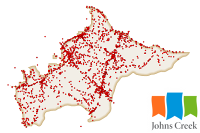

In [5]:
item

## Interpolate - sync, output FC

In [6]:
result = interpolate_points(item.layers[0],
                            field='UnitsInvolved',
                            interpolate_option=5,
                            output_prediction_error=True,
                            classification_type='EqualArea',
                            num_classes=5)

In [7]:
assert isinstance(result, dict)
assert isinstance(result['result_layer'], FeatureCollection)
assert isinstance(result['prediction_error'], FeatureCollection)

## Interpolate - sync, output Feature Service

In [8]:
from datetime import datetime
result = interpolate_points(item.layers[0],
                            field='UnitsInvolved',
                            interpolate_option=5,
                            output_prediction_error=True,
                            classification_type='EqualArea',
                            num_classes=5,
                            output_name='interpolate acidents' + str(datetime.now().microsecond))

In [9]:
assert isinstance(result, Item)
result.delete()

True

## Interpolate - async, output FC

In [10]:
result = interpolate_points(item.layers[0],
                            field='UnitsInvolved',
                            interpolate_option=9,
                            output_prediction_error=True,
                            classification_type='EqualArea',
                            num_classes=5,
                            future=True)

In [11]:
assert isinstance(result, GPJob)
assert isinstance(result.result(), dict)
assert isinstance(result.result()['result_layer'], FeatureCollection)
assert isinstance(result.result()['prediction_error'], FeatureCollection)

## Interpolate - estimate

In [12]:
est_result = interpolate_points(item.layers[0],
                            field='UnitsInvolved',
                            interpolate_option=9,
                            output_prediction_error=True,
                            classification_type='EqualArea',
                            num_classes=5,
                            estimate=True)

In [13]:
est_result

23.18